# Hybrid Movie Recommendation System (CF + CBF)
Notebook ini berisi logika yang sama dengan `app.py` untuk bereksperimen menggunakan Hybrid Filtering (50% CF + 50% CBF).

In [2]:
import pandas as pd
import difflib
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Load Datasets
movies_path = '../dataset/movies_metadata.csv'
ratings_path = '../dataset/ratings_small.csv'
links_path = '../dataset/links_small.csv'

df_movies = pd.read_csv(movies_path, low_memory=False)
df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_movies = df_movies.dropna(subset=['id', 'title'])
df_movies['id'] = df_movies['id'].astype(int)
df_movies = df_movies.drop_duplicates(subset=['title'])

df_links = pd.read_csv(links_path)
df_links = df_links.dropna(subset=['tmdbId'])
df_links['tmdbId'] = df_links['tmdbId'].astype(int)

# Filter dataset untuk menghemat memori (hanya gunakan film yang ada di links_small)
df_movies = df_movies[df_movies['id'].isin(df_links['tmdbId'])]

print(f"Total film yang diproses: {len(df_movies)}")

Total film yang diproses: 8695


## 2. Content-Based Filtering (CBF)

In [4]:
df_movies['overview'] = df_movies['overview'].fillna('')
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_movies['overview'])

cbf_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
cbf_similarity_df = pd.DataFrame(cbf_sim_matrix, index=df_movies['title'], columns=df_movies['title'])

print("CBF Matrix Berhasil Dibuat!")

CBF Matrix Berhasil Dibuat!


## 3. Collaborative Filtering (CF)

In [5]:
df_ratings = pd.read_csv(ratings_path)
df_ratings = df_ratings.merge(df_links[['movieId', 'tmdbId']], on='movieId', how='inner')
df_ratings = df_ratings.rename(columns={'tmdbId': 'id'})
df_ratings = df_ratings.merge(df_movies[['id', 'title']], on='id', how='inner')

user_movie_matrix = df_ratings.pivot_table(index='title', columns='userId', values='rating').fillna(0)
cf_sim_matrix = cosine_similarity(user_movie_matrix)
cf_similarity_df = pd.DataFrame(cf_sim_matrix, index=user_movie_matrix.index, columns=user_movie_matrix.index)

print("CF Matrix Berhasil Dibuat!")

CF Matrix Berhasil Dibuat!


## 4. Fungsi Rekomendasi (Hybrid)

In [6]:
def get_hybrid_recommendations(movie_title, top_n=5):
    all_titles = cbf_similarity_df.columns.tolist()
    close_matches = difflib.get_close_matches(movie_title, all_titles, n=1, cutoff=0.3)
    
    if not close_matches:
        return "Film tidak ditemukan."
        
    matched_title = close_matches[0]
    
    # Ambil Skor CBF
    cbf_scores = cbf_similarity_df[matched_title]
    
    # Ambil Skor CF
    if matched_title in cf_similarity_df.columns:
        cf_scores = cf_similarity_df[matched_title]
    else:
        cf_scores = pd.Series(0, index=cbf_similarity_df.columns)
        
    # Sejajarkan index CF dan CBF, isi dengan 0 jika NaN
    cf_scores = cf_scores.reindex(cbf_scores.index).fillna(0)
    
    # Perhitungan Bobot: 50% CF + 50% CBF
    hybrid_scores = (0.5 * cf_scores) + (0.5 * cbf_scores)
    
    if matched_title in hybrid_scores:
        hybrid_scores = hybrid_scores.drop(matched_title)
        
    return hybrid_scores.sort_values(ascending=False).head(top_n)

print("Fungsi Hybrid siap digunakan!")

Fungsi Hybrid siap digunakan!


In [7]:
print("Rekomendasi untuk 'The Dark Knight Rises':")
get_hybrid_recommendations("The Dark Knight Rises")

Rekomendasi untuk 'The Dark Knight Rises':


title
The Dark Knight                       0.424984
Batman Begins                         0.315079
Inception                             0.294654
Avatar                                0.286295
Captain America: The First Avenger    0.281466
Name: The Dark Knight Rises, dtype: float64

## 5. Evaluasi Sistem Rekomendasi

In [13]:
!pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


Memulai Evaluasi Model Recommender System...

--- HASIL EVALUASI METRIK HYBRID ---
Accuracy  : 0.73
Precision : 0.73
Recall    : 1.00
F1 Score  : 0.85


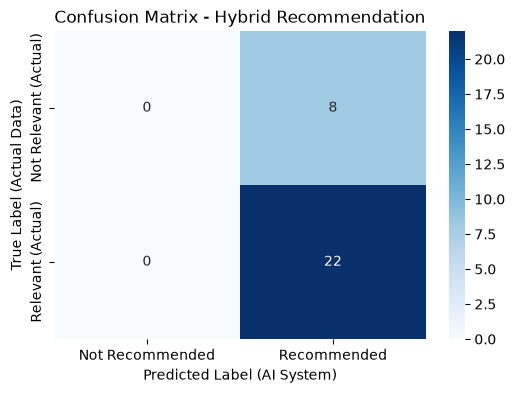

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Memulai Evaluasi Model Recommender System...")

# 1. Tentukan batas (threshold) untuk klasifikasi
RATING_THRESHOLD = 3.5  # Film dianggap 'Relevan' jika rating rata-rata >= 3.5
SCORE_THRESHOLD = 0.1   # Film dianggap 'Direkomendasikan' sistem jika Skor Hybrid >= 0.1

# 2. Hitung rata-rata rating aktual tiap film sebagai Ground Truth
# (Menggunakan dataset rating yang sudah kamu panggil sebelumnya)
average_ratings = df_ratings.groupby('title')['rating'].mean()

# 3. Buat fungsi simulasi evaluasi
def evaluate_hybrid_model(test_movie_title, top_n=20):
    # Ambil skor hybrid untuk semua film
    all_titles = cbf_similarity_df.columns.tolist()
    close_matches = difflib.get_close_matches(test_movie_title, all_titles, n=1, cutoff=0.3)
    
    if not close_matches:
        return "Film tidak ditemukan."
    
    matched_title = close_matches[0]
    
    # Ambil skor
    cbf_scores = cbf_similarity_df[matched_title]
    if matched_title in cf_similarity_df.columns:
        cf_scores = cf_similarity_df[matched_title]
    else:
        cf_scores = pd.Series(0, index=cbf_similarity_df.columns)
        
    cf_scores = cf_scores.reindex(cbf_scores.index).fillna(0)
    hybrid_scores = (0.5 * cf_scores) + (0.5 * cbf_scores)
    if matched_title in hybrid_scores:
        hybrid_scores = hybrid_scores.drop(matched_title)
        
    # Ambil top N sampel untuk dievaluasi
    sample_scores = hybrid_scores.sort_values(ascending=False).head(top_n)
    
    y_actual = []
    y_pred = []
    
    for title, score in sample_scores.items():
        # GROUND TRUTH: Apakah aslinya film ini bagus?
        actual_rating = average_ratings.get(title, 0)
        is_relevant_actual = 1 if actual_rating >= RATING_THRESHOLD else 0
        y_actual.append(is_relevant_actual)
        
        # PREDIKSI SISTEM: Apakah sistem merekomendasikan dengan kuat?
        is_recommended_pred = 1 if score >= SCORE_THRESHOLD else 0
        y_pred.append(is_recommended_pred)
        
    return y_actual, y_pred

# 4. Jalankan Pengujian
y_true, y_pred = evaluate_hybrid_model("The Dark Knight Rises", top_n=30)

# 5. Hitung Metrik Evaluasi Matematika
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)

# Tambahan F1 Score
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"\n--- HASIL EVALUASI METRIK HYBRID ---")
print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1 Score  : {f1:.2f}")

# 6. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Recommended', 'Recommended'], 
            yticklabels=['Not Relevant (Actual)', 'Relevant (Actual)'])
plt.title('Confusion Matrix - Hybrid Recommendation')
plt.xlabel('Predicted Label (AI System)')
plt.ylabel('True Label (Actual Data)')
plt.show()

Precision: Seberapa akurat rekomendasi AI. Rumusnya: $Precision = \frac{TP}{TP+FP}$

Recall: Seberapa banyak film relevan yang berhasil ditemukan AI. Rumusnya: $Recall = \frac{TP}{TP+FN}$

Accuracy: Seberapa sering AI benar secara keseluruhan. Rumusnya: $Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$

$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$